# **The Dataset - Telco Customer Churn**

Customer churn is a critical challenge for subscription-based businesses, as acquiring new customers is significantly more expensive than retaining existing ones.   

The objective of this project is to analyze customer behavior in a subscription-based telecom company and build a predictive model to identify customers who are likely to churn. Not only limiting the scope of this project to prediction, the goal is to understand the key drivers of churn and translate model insights into actionable retention strategies that the company can actually use for its customers. Therefore, the ***Telco Customer Churn Dataset*** serves as the foundation for this analysis.

# Dataset Description

The dataset contains customer demographics, subscription details, service usage, and billing information, along with a churn indicator showing whether a customer left the service.

This dataset is well-suited for churn analysis as it mirrors real-world subscription business data and enables both predictive modeling and business-driven analysis.

# Project Objectives

The key objectives of this analysis are:
- To explore behavioral and contractual differences between churned and retained customers
- To identify which factors most strongly influence customer churn
- To build a machine learning model that predicts churn risk
- To derive actionable insights that can inform customer retention strategies

Evaluation Metric: Because only about 27% of customers churn, ROC-AUC is used as the primary model selection metric, while recall and the F2 score are emphasized to reflect the business objective of minimizing missed churners.

# Data Loading and Inspection

In [109]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sbn
sbn.set(style = 'whitegrid')

In [110]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [111]:
print("shape of df:", df.shape)
print()
df.info()

shape of df: (7043, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling 

### **Initial Observations**

- The dataset contains both numerical and categorical features.
- The `TotalCharges` column appears to be stored as a string and will require cleaning.
- The target variable `Churn` is categorical and will be encoded later.

# Data Cleaning

Data Cleaning here is important as removing a small number of incomplete records avoids introducing noise without affecting overall patterns. It will also be beneficial and effective to remove non-informative columns that possess no prediction value.

In [112]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = 'coerce')
print(df.isna().sum())
df = df.dropna()
df = df.drop(columns= ["customerID"])
print()
print("new shape of df:", df.shape)

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

new shape of df: (7032, 20)


### **Cleaning Summary:**
- Converted `TotalCharges` to numeric and removed incomplete records
- Dropped customer identifier column
- Retained all behavioral, contractual, and billing features for analysis

# Target Variable - Churn

In [113]:
df["Churn"] = df["Churn"].str.strip().str.upper().map({"YES": 1, "NO": 0})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [114]:
df["Churn"].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

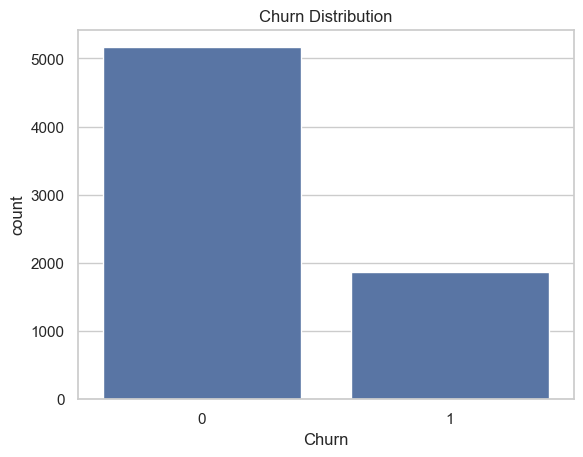

In [115]:
sbn.countplot(x = 'Churn', data = df)
plt.title('Churn Distribution')
plt.show()

**Insight:**  
Roughly 27% of customers churned, indicating a significant retention challenge. The dataset is imbalanced, so evaluation should prioritize identifying churners rather than relying solely on overall accuracy.  

A naive model that predicts every customer stays would achieve about 73% accuracy but fail completely at detecting churners. Therefore, metrics like recall, precision, and F1-score for the churn class are far more meaningful than accuracy in this scenario.

# Core EDA - What Drives Churn?

## Tenure vs Churn

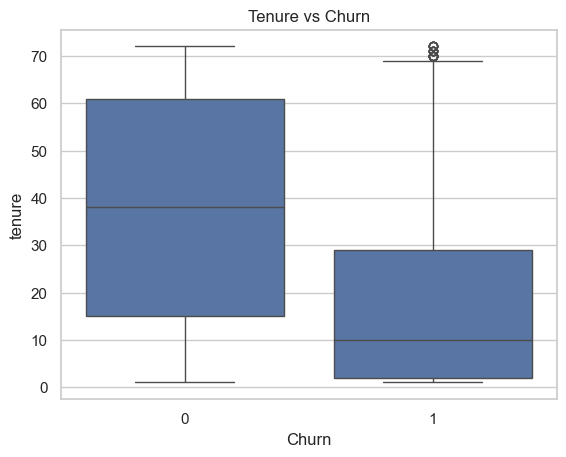

In [116]:
sbn.boxplot(x = "Churn", y = "tenure", data = df)
plt.title("Tenure vs Churn")
plt.show()

**Insight:**  
Customers who churn tend to have significantly shorter tenure, indicating that churn risk is highest early in the customer lifecycle.

## Contract Type vs Churn

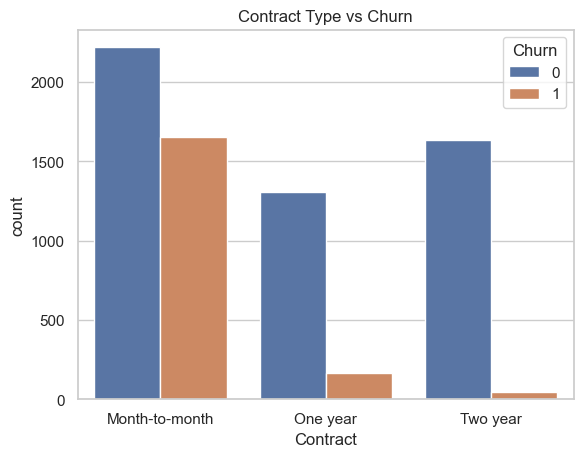

In [117]:
sbn.countplot(x = "Contract", hue = "Churn", data = df)
plt.title("Contract Type vs Churn")
plt.show()

**Insight:**  
Customers on month-to-month contracts churn at a much higher rate than those on longer-term contracts, highlighting commitment level as a key retention factor.

## Monthly Charges vs Churn

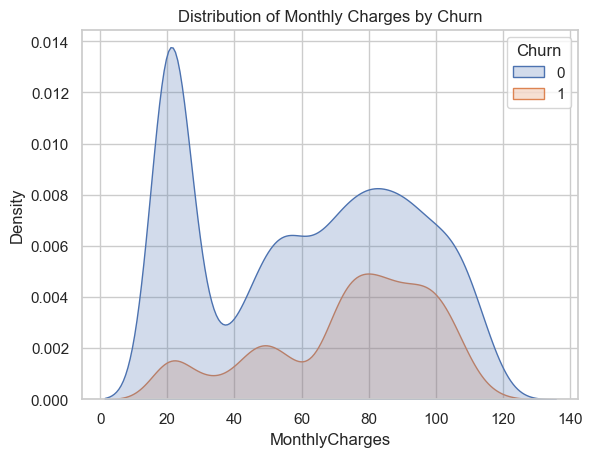

In [118]:
sbn.kdeplot(x = "MonthlyCharges", hue = "Churn", data=df, fill = True)
plt.title("Distribution of Monthly Charges by Churn")
plt.show()

**Insight:**  
Customers with higher monthly charges are more likely to churn, suggesting price sensitivity plays a role, particularly among less-tenured users.

## Service Engagement vs Churn

### 1. Individual Services vs Churn

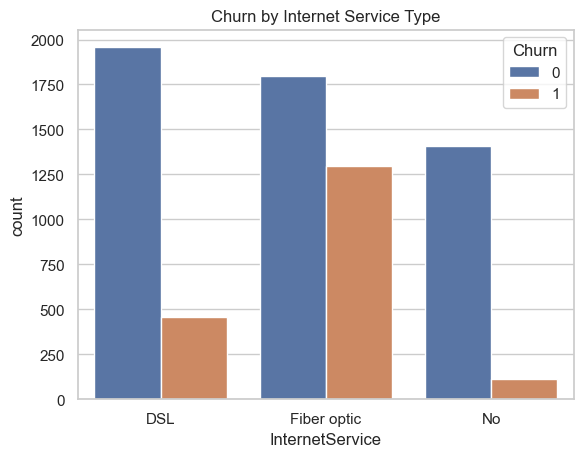

In [119]:
sbn.countplot(x = "InternetService", hue = "Churn", data = df)
plt.title("Churn by Internet Service Type")
plt.show()

### 2. Tech Support vs Churn

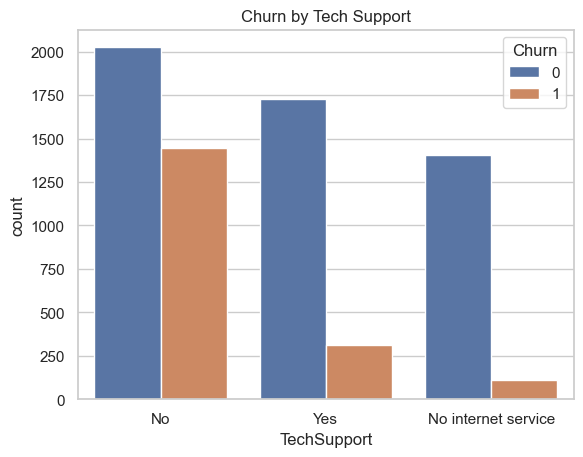

In [120]:
sbn.countplot(x="TechSupport", hue="Churn", data=df)
plt.title("Churn by Tech Support")
plt.show()

### 3. Streaming & Add-on Services

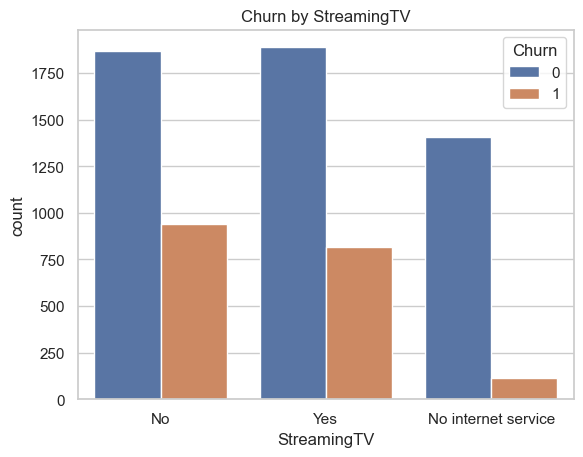

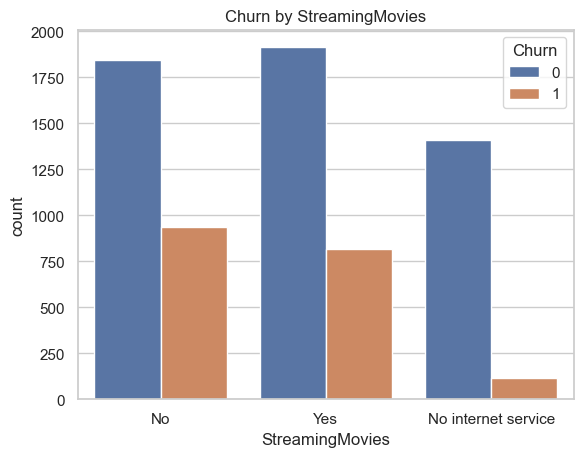

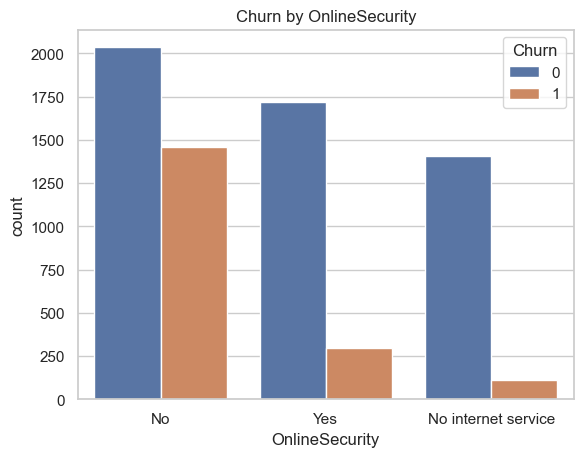

In [121]:
services = ["StreamingTV", "StreamingMovies", "OnlineSecurity"]

for service in services:
    sbn.countplot(x = service, hue = "Churn", data = df)
    plt.title(f"Churn by {service}")
    plt.show()

### **Insight:**  
Customers with fewer subscribed services, particularly those lacking support and security features, are more likely to churn. This suggests that deeper service engagement increases customer stickiness and reduces churn risk.

# Feature Engineering

## Tenure Blocks

In [122]:
from sklearn.preprocessing import OrdinalEncoder

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "12-24", "24-48", "48+"]
)

tenure_order = [["0-12", "12-24", "24-48", "48+"]]
encoder = OrdinalEncoder(categories = tenure_order)
df["tenure_group_encoded"] = encoder.fit_transform(df[["tenure_group"]])

df = df.drop(columns=["tenure_group"])

## Contract Commitment Level

In [123]:
contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}

df["contract_commitment"] = df["Contract"].map(contract_map)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group_encoded,contract_commitment
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0.0,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,2.0,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0.0,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2.0,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0.0,0


## Engagement Score

In [124]:
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

df["engagement_score"] = (df[service_cols] == "Yes").sum(axis = 1)

## Price Intensity

In [125]:
df["charges_per_tenure"] = df["MonthlyCharges"] / (df["tenure"] + 1)

### **Feature Engineering Summary:**
- Created lifecycle-based tenure groups to capture early vs late churn behavior  
- Encoded contract commitment as an ordered feature reflecting switching friction  
- Aggregated service usage into an engagement score  
- Normalized pricing by tenure to approximate price sensitivity

# Encoding and Train-Test Split

All engineered features were derived solely from information available at prediction time, ensuring no target leakage.

In [126]:
X = df.drop(columns=["Churn", "Contract"])
y = df["Churn"]

categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,tenure_group_encoded,contract_commitment,engagement_score,charges_per_tenure,gender_Male,Partner_Yes,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0.0,0,1,14.925000,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,2.0,1,2,1.627143,True,False,...,False,False,False,False,False,False,False,False,False,True
2,0,2,53.85,108.15,0.0,0,2,17.950000,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,2.0,1,3,0.919565,True,False,...,False,True,False,False,False,False,False,False,False,False
4,0,2,70.70,151.65,0.0,0,0,23.566667,False,False,...,False,False,False,False,False,False,True,False,True,False


In [127]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size = 0.2, random_state = 856, stratify = y)

In [128]:
X_train.shape, X_test.shape

((5625, 32), (1407, 32))

### **Encoding and Split Summary:**

**Preparation Summary:**
- Separated target variable to avoid data leakage  
- One-hot encoded categorical features for model compatibility  
- Applied stratified train-test split to preserve churn distribution

# Baseline Model: Logistic Regression

## Training the Model

In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter = 1000, random_state = 856, class_weight = "balanced")
model.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,856
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Making Predictions

In [130]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

## ROC-AUC

In [131]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {roc_auc:.3f}")

ROC-AUC: 0.843


## Classification Report

In [132]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.77      0.72      1407
weighted avg       0.81      0.75      0.76      1407



## Confusion matrix

In [133]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[749 284]
 [ 72 302]]


## HeatMap

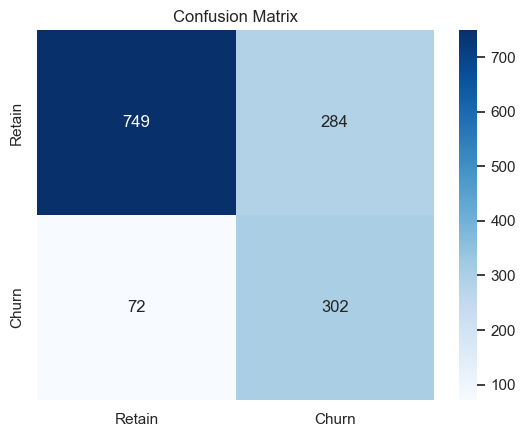

In [134]:
sbn.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", xticklabels = ["Retain", "Churn"], yticklabels = ["Retain", "Churn"])
plt.title("Confusion Matrix")
plt.show()

In [135]:
coef_df = pd.DataFrame({"Feature": X_train.columns, "Coefficient": model.coef_[0]}).sort_values(by = "Coefficient", ascending = False)

coef_df.head(10)

,Feature,Coefficient
12,MultipleLines_No phone service,0.562637
14,InternetService_Fiber optic,0.414136
28,PaperlessBilling_Yes,0.321279
25,StreamingTV_Yes,0.278859
0,SeniorCitizen,0.231343
30,PaymentMethod_Electronic check,0.196461
27,StreamingMovies_Yes,0.191374
13,MultipleLines_Yes,0.171864
4,tenure_group_encoded,0.043464
7,charges_per_tenure,0.043272


# Tree Based Model: Random Forest

## Training the Model

In [136]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 300, random_state = 856, class_weight = "balanced", max_depth = None, n_jobs = -1)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Making Predictions

In [137]:
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

## ROC-AUC

In [138]:
rf_roc_auc = roc_auc_score(y_test, rf_prob)
print(f"Random Forest ROC-AUC: {rf_roc_auc:.3f}")

Random Forest ROC-AUC: 0.824


## Classification Report

In [139]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.48      0.56       374

    accuracy                           0.80      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.80      0.78      1407



## Confusion Matrix

In [140]:
rf_cm = confusion_matrix(y_test, rf_pred)
print(rf_cm)

[[941  92]
 [195 179]]


## HeatMap

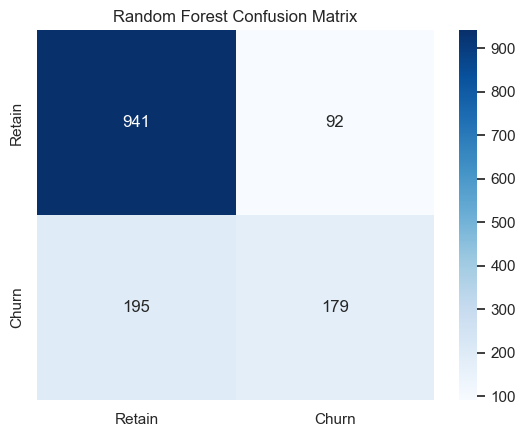

In [141]:
sbn.heatmap(rf_cm, annot = True, fmt = "d", cmap = "Blues", xticklabels = ["Retain", "Churn"], yticklabels = ["Retain", "Churn"])
plt.title("Random Forest Confusion Matrix")
plt.show()

## Feature Importance

In [142]:
feature_importance = pd.DataFrame({"Feature": X_train.columns, "Importance": rf.feature_importances_}).sort_values(by = "Importance", ascending = False)

feature_importance

,Feature,Importance
7,charges_per_tenure,0.183060
3,TotalCharges,0.120621
2,MonthlyCharges,0.114528
1,tenure,0.101482
5,contract_commitment,0.083285
14,InternetService_Fiber optic,0.036204
4,tenure_group_encoded,0.034745
6,engagement_score,0.030597
30,PaymentMethod_Electronic check,0.025913
8,gender_Male,0.021344


# Gradient Boosted Model: XGBoost

## Training the Model

XGBoost is introduced as a gradient-boosted alternative to the bagged Random Forest. Boosting builds trees sequentially, each correcting the previous one's errors, which often captures feature interactions (e.g., tenure combined with contract type) more effectively than a single linear model or a bagged ensemble.

In [143]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    random_state=856,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    n_jobs=-1
)
xgb.fit(X_train, y_train)
print("Model trained")

Model trained


## Making Predictions

In [144]:
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

## ROC-AUC

In [145]:
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)
print(f"XGBoost ROC-AUC: {xgb_roc_auc:.3f}")

XGBoost ROC-AUC: 0.801


## Classification Report

In [146]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1033
           1       0.56      0.59      0.57       374

    accuracy                           0.77      1407
   macro avg       0.70      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407



## Confusion Matrix

In [147]:
xgb_cm = confusion_matrix(y_test, xgb_pred)
print(xgb_cm)

[[859 174]
 [153 221]]


## HeatMap

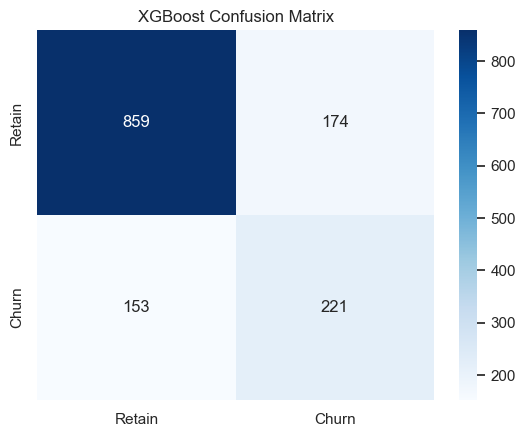

In [148]:
sbn.heatmap(xgb_cm, annot = True, fmt = "d", cmap = "Blues", xticklabels = ["Retain", "Churn"], yticklabels = ["Retain", "Churn"])
plt.title("XGBoost Confusion Matrix")
plt.show()

## Feature Importance

In [149]:
xgb_importance = pd.DataFrame({"Feature": X_train.columns, "Importance": xgb.feature_importances_}).sort_values(by = "Importance", ascending = False)
xgb_importance.head(10)

,Feature,Importance
5,contract_commitment,0.308021
14,InternetService_Fiber optic,0.270644
15,InternetService_No,0.043180
11,PhoneService_Yes,0.037731
7,charges_per_tenure,0.026563
23,TechSupport_Yes,0.021901
27,StreamingMovies_Yes,0.020021
28,PaperlessBilling_Yes,0.019084
17,OnlineSecurity_Yes,0.017505
30,PaymentMethod_Electronic check,0.017439


# Margin-Based Model: Support Vector Machine

## Feature Scaling

Unlike Logistic Regression and Random Forest, SVMs are sensitive to feature magnitude since they rely on distances in feature space. Numeric and encoded features are scaled before training.

In [150]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Training the Model

In [151]:
svm = SVC(probability=True, random_state=856, class_weight="balanced")
svm.fit(X_train_scaled, y_train)
print("Model trained.")

Model trained.


## Making Predictions

In [152]:
svm_pred = svm.predict(X_test_scaled)
svm_prob = svm.predict_proba(X_test_scaled)[:, 1]

## ROC-AUC

In [153]:
svm_roc_auc = roc_auc_score(y_test, svm_prob)
print(f"SVM ROC-AUC: {svm_roc_auc:.3f}")

SVM ROC-AUC: 0.827


## Classification Report

In [154]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1033
           1       0.52      0.83      0.64       374

    accuracy                           0.75      1407
   macro avg       0.72      0.77      0.72      1407
weighted avg       0.81      0.75      0.76      1407



## Confusion Matrix

In [155]:
svm_cm = confusion_matrix(y_test, svm_pred)
print(svm_cm)

[[745 288]
 [ 65 309]]


## HeatMap

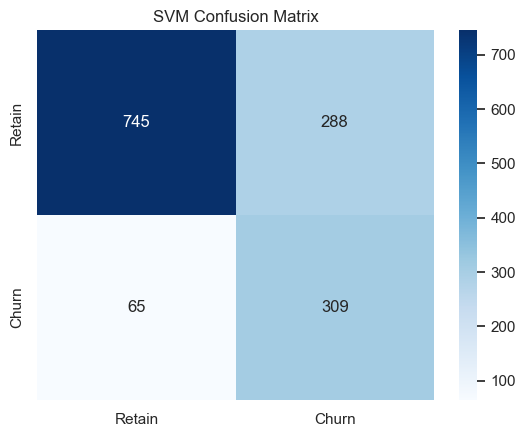

In [156]:
sbn.heatmap(svm_cm, annot = True, fmt = "d", cmap = "Blues", xticklabels = ["Retain", "Churn"], yticklabels = ["Retain", "Churn"])
plt.title("SVM Confusion Matrix")
plt.show()

### **Model Comparison:**
- Logistic Regression achieves the highest baseline ROC-AUC (0.843) and strong recall for churned 
  customers (0.81), along with full interpretability through its coefficients — a stronger baseline result 
  than before the encoding fix, now that categorical features like `InternetService` and `PaymentMethod` 
  are properly represented.
- SVM (ROC-AUC 0.827) performs very similarly to Logistic Regression, with the highest recall of all four 
  models (0.83) — likely because both rely on a broadly linear-style separation once features are scaled. 
  Unlike Logistic Regression, SVM does not provide feature-level interpretability, since the RBF kernel 
  operates on distances in a transformed feature space rather than direct feature weights.
- Random Forest (ROC-AUC 0.824) trades recall for precision compared to the other three models — its 
  recall for churned customers (0.48) is noticeably lower, but its precision (0.66) is the highest, meaning 
  it misses more churners but is more confident when it does flag one.
- XGBoost (ROC-AUC 0.801) is the weakest baseline performer, with balanced but middling precision (0.56) 
  and recall (0.59) — consistent with untuned boosted trees being sensitive to default hyperparameters and 
  needing tuning to reach their real potential, a pattern this notebook revisits and corrects in the 
  Hyperparameter Tuning section.

At this baseline stage, Logistic Regression is the strongest performer on both ROC-AUC and recall for the 
target class — a result this notebook re-examines after proper tuning, since untuned tree-based models are 
known to be sensitive to their default hyperparameters.

# Hyperparameter Tuning & Cross-Validation

The baseline models above were trained using mostly default parameters and evaluated on a single 
train/test split. This gives a reasonable first look, but doesn't confirm whether the models are 
well-tuned or how stable their performance is across different subsets of data. All four models are 
now tuned using RandomizedSearchCV with 5-fold stratified cross-validation, optimizing for ROC-AUC.

In [157]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=856)

## Tuning Logistic Regression

In [158]:
lr_param_dist = {
    "C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=856, class_weight="balanced"),
    param_distributions=lr_param_dist,
    n_iter=16,
    scoring="roc_auc",
    cv=cv,
    random_state=856,
    n_jobs=-1
)
lr_search.fit(X_train, y_train)
best_lr = lr_search.best_estimator_

print("Best LR params:", lr_search.best_params_)
print(f"LR CV ROC-AUC: {lr_search.best_score_:.4f} +/- "
      f"{lr_search.cv_results_['std_test_score'][lr_search.best_index_]:.4f}")

best_lr_test_auc = roc_auc_score(y_test, best_lr.predict_proba(X_test)[:, 1])
print(f"LR test ROC-AUC: {best_lr_test_auc:.4f}")

Best LR params: {'solver': 'liblinear', 'penalty': 'l1', 'C': 3}
LR CV ROC-AUC: 0.8496 +/- 0.0109
LR test ROC-AUC: 0.8427


## Tuning Random Forest

In [159]:
rf_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [None, 6, 10, 14, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=856, class_weight="balanced", n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    random_state=856,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("Best RF params:", rf_search.best_params_)
print(f"RF CV ROC-AUC: {rf_search.best_score_:.4f} +/- "
      f"{rf_search.cv_results_['std_test_score'][rf_search.best_index_]:.4f}")

best_rf_test_auc = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])
print(f"RF test ROC-AUC: {best_rf_test_auc:.4f}")

Best RF params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 6}
RF CV ROC-AUC: 0.8454 +/- 0.0110
RF test ROC-AUC: 0.8400


## Tuning XGBoost

In [160]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        random_state=856,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        n_jobs=-1
    ),
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=856,
    n_jobs=-1
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print("Best XGBoost params:", xgb_search.best_params_)
print(f"XGBoost CV ROC-AUC: {xgb_search.best_score_:.4f} +/- "
      f"{xgb_search.cv_results_['std_test_score'][xgb_search.best_index_]:.4f}")

best_xgb_test_auc = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1])
print(f"XGBoost test ROC-AUC: {best_xgb_test_auc:.4f}")

Best XGBoost params: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
XGBoost CV ROC-AUC: 0.8489 +/- 0.0106
XGBoost test ROC-AUC: 0.8444


## Tuning SVM

SVM tuning reuses the scaled features (`X_train_scaled`, `X_test_scaled`) from the baseline SVM section.

In [161]:
svm_param_dist = {
    "C": [0.1, 0.3, 1, 3, 10, 30],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    "kernel": ["rbf"]
}

svm_search = RandomizedSearchCV(
    SVC(probability=True, random_state=856, class_weight="balanced"),
    param_distributions=svm_param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    random_state=856,
    n_jobs=-1
)
svm_search.fit(X_train_scaled, y_train)
best_svm = svm_search.best_estimator_

print("Best SVM params:", svm_search.best_params_)
print(f"SVM CV ROC-AUC: {svm_search.best_score_:.4f} +/- "
      f"{svm_search.cv_results_['std_test_score'][svm_search.best_index_]:.4f}")

best_svm_test_auc = roc_auc_score(y_test, best_svm.predict_proba(X_test_scaled)[:, 1])
print(f"SVM test ROC-AUC: {best_svm_test_auc:.4f}")

Best SVM params: {'kernel': 'rbf', 'gamma': 0.001, 'C': 10}
SVM CV ROC-AUC: 0.8482 +/- 0.0113
SVM test ROC-AUC: 0.8395


### Four-Way Model Comparison

|                      | CV ROC-AUC        | Test ROC-AUC |
|----------------------|--------------------|--------------|
| Logistic Regression  | 0.8496 ± 0.0109   | 0.8427       |
| Random Forest        | 0.8454 ± 0.0110   | 0.8400       |
| XGBoost              | 0.8489 ± 0.0106   | 0.8444       |
| SVM                  | 0.8482 ± 0.0113   | 0.8395       |

After tuning, all four models converge to an even tighter band (0.8395–0.8444 test ROC-AUC) than before the 
encoding fix, with XGBoost coming out only narrowly ahead. Logistic Regression, meanwhile, closed almost 
the entire gap it previously had with XGBoost — the tuned models now differ by roughly 0.005 ROC-AUC at 
most, reinforcing that model choice here should be driven by interpretability and business needs rather 
than raw accuracy.

# Threshold Tuning and Decision Layer

## Generating Tuned Probabilities

In [162]:
best_lr_prob = best_lr.predict_proba(X_test)[:, 1]
best_rf_prob = best_rf.predict_proba(X_test)[:, 1]
best_xgb_prob = best_xgb.predict_proba(X_test)[:, 1]
best_svm_prob = best_svm.predict_proba(X_test_scaled)[:, 1]

# ROC Curve, Precision-Recall Curve, and Threshold Optimization

## ROC Curves — All Models

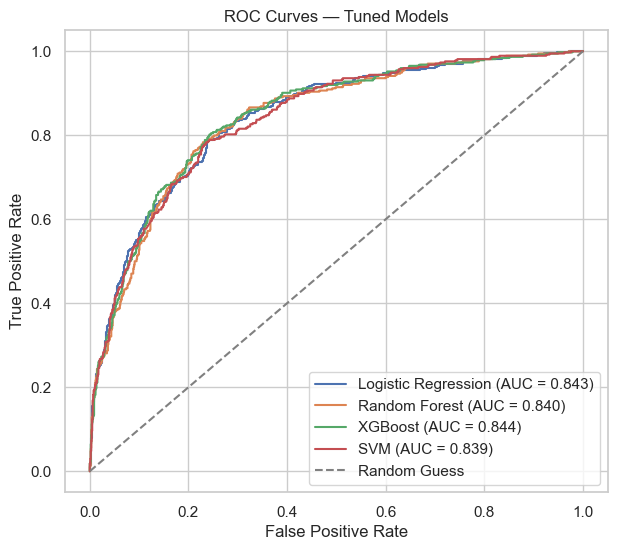

In [163]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))

for name, prob in [
    ("Logistic Regression", best_lr_prob),
    ("Random Forest", best_rf_prob),
    ("XGBoost", best_xgb_prob),
    ("SVM", best_svm_prob),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Tuned Models")
plt.legend()
plt.show()

## Precision-Recall Curves — All Models

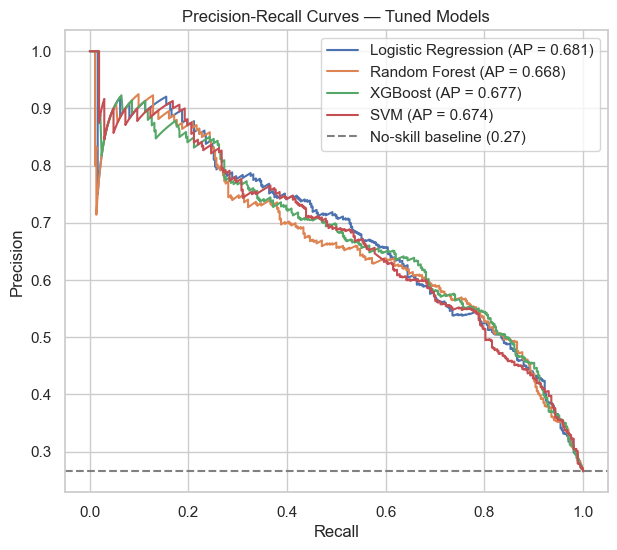

In [164]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7, 6))

for name, prob in [
    ("Logistic Regression", best_lr_prob),
    ("Random Forest", best_rf_prob),
    ("XGBoost", best_xgb_prob),
    ("SVM", best_svm_prob),
]:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})")

baseline = y_test.mean()
plt.axhline(baseline, linestyle="--", color="gray", label=f"No-skill baseline ({baseline:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Tuned Models")
plt.legend()
plt.show()

## Threshold Optimization via F-beta Score

Rather than manually comparing a few fixed thresholds, the optimal threshold is derived directly from 
the precision-recall curve using an F-beta score. Beta > 1 weights recall more heavily than precision, 
which matches the business priority established earlier: missing a churner is costlier than an 
unnecessary retention offer to a customer who wouldn't have churned. A beta of 2 is used here, meaning 
recall is weighted twice as heavily as precision.

In [165]:
def optimal_threshold_fbeta(y_true, y_prob, beta=2):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    # drop the last precision/recall point (has no corresponding threshold)
    precision, recall = precision[:-1], recall[:-1]
    fbeta = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + 1e-9)
    best_idx = fbeta.argmax()
    return thresholds[best_idx], fbeta[best_idx], precision[best_idx], recall[best_idx]

for name, prob in [
    ("Logistic Regression", best_lr_prob),
    ("Random Forest", best_rf_prob),
    ("XGBoost", best_xgb_prob),
    ("SVM", best_svm_prob),
]:
    t, f, p, r = optimal_threshold_fbeta(y_test, prob, beta=2)
    print(f"{name}: optimal threshold = {t:.3f} | F2 = {f:.3f} | precision = {p:.3f} | recall = {r:.3f}")

Logistic Regression: optimal threshold = 0.298 | F2 = 0.747 | precision = 0.424 | recall = 0.922
Random Forest: optimal threshold = 0.432 | F2 = 0.752 | precision = 0.492 | recall = 0.866
XGBoost: optimal threshold = 0.371 | F2 = 0.754 | precision = 0.455 | recall = 0.901
SVM: optimal threshold = 0.144 | F2 = 0.740 | precision = 0.435 | recall = 0.898


## Interpretation

### ROC Curves
All four models produce nearly overlapping ROC curves, confirming what the tuning results already showed — 
they're statistically close in discriminative power (AUC 0.839–0.844 here). XGBoost sits marginally above 
the rest across most of the curve, consistent with its slightly higher ROC-AUC from tuning.

### Precision-Recall Curves
The PR curves are more informative than ROC here, since churn is an imbalanced problem (~27% positive 
class — the no-skill baseline sits at 0.27, and all four models sit comfortably above it). Logistic 
Regression now has the highest average precision (0.681), narrowly ahead of XGBoost (0.677), Random Forest 
(0.668), and SVM (0.674). The curves converge heavily in the 0.4–0.8 recall range, meaning the practical 
difference between models mostly shows up at the extremes — very high or very low recall — rather than in 
the operating range a business would actually use.

### F2-Optimal Thresholds
Optimizing directly for F2 (recall weighted 2x precision) rather than eyeballing fixed values gives:

| Model | Optimal Threshold | F2 | Precision | Recall |
|-------|-------------------|-----|-----------|--------|
| Logistic Regression | 0.298 | 0.747 | 0.424 | 0.922 |
| Random Forest        | 0.432 | 0.752 | 0.492 | 0.866 |
| XGBoost               | 0.371 | 0.754 | 0.455 | 0.901 |
| SVM                   | 0.144 | 0.740 | 0.435 | 0.898 |

Logistic Regression's optimal threshold (0.298) is notably lower than the other three models' - a 
reflection of how its probability estimates are distributed relative to the decision boundary, not a sign 
of weaker performance. All four models land on similar F2 scores (0.740–0.754) at their respective optimal 
thresholds, reinforcing that model choice here should be driven by interpretability rather than any 
meaningful performance gap. Random Forest and XGBoost narrowly edge out Logistic Regression on F2 itself, 
but the margin (0.005–0.007) is well within the range where interpretability is the deciding factor.

# Probability Calibration

## Calibration Curve and Brier Score

Since deployment decisions rely directly on predicted probabilities, calibration is evaluated to verify whether predicted churn probabilities correspond to observed churn frequencies. A well-calibrated model allows probability thresholds to be interpreted as meaningful business risk estimates rather than simply model scores.

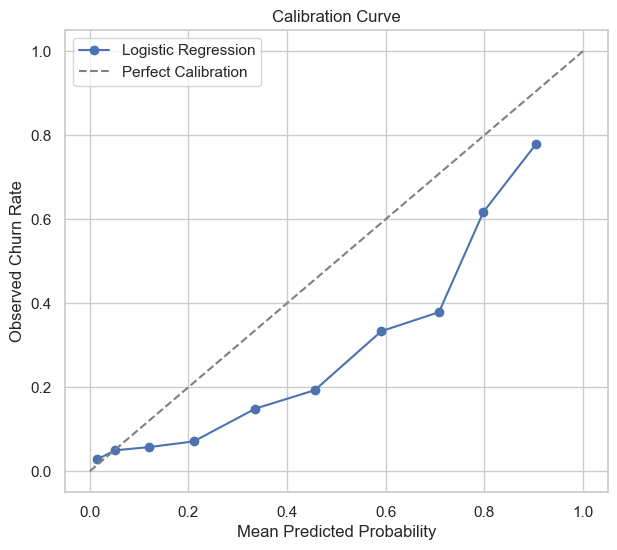

Brier Score: 0.1679


In [166]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(
    y_test,
    best_lr_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7,6))
plt.plot(prob_pred, prob_true, marker="o", label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Churn Rate")
plt.title("Calibration Curve")
plt.legend()
plt.show()

brier = brier_score_loss(y_test, best_lr_prob)
print(f"Brier Score: {brier:.4f}")

## Interpretation

The calibration curve indicates that Logistic Regression slightly overestimates churn probabilities, particularly at higher predicted risk levels. However, the relationship remains monotonic, making the model suitable for ranking customers by churn risk and supporting threshold-based retention decisions. The Brier Score further summarizes overall probability calibration, with lower values indicating better calibrated predictions.

## **--> Chosen Threshold - 0.298**

In [167]:
chosen_threshold = 0.298

### Why 0.298?

Rather than using the default classification threshold of 0.5, the final threshold was selected by maximizing the F2 score. This places greater emphasis on recall than precision, reflecting the business objective of minimizing missed churners even if it results in additional false positives.

# Error Analysis

## Categorizing Predictions

Using the final threshold (0.298) on Logistic Regression's tuned probabilities, every test customer is 
labeled as a true positive, true negative, false positive, or false negative. Comparing the false positives 
(flagged as churn risk but stayed) against false negatives (missed churners) can reveal whether the model 
is systematically confused by a particular customer profile, rather than just failing randomly.

In [168]:
error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["predicted_prob"] = best_lr_prob
error_df["predicted"] = (error_df["predicted_prob"] >= chosen_threshold).astype(int)

def error_category(row):
    if row["actual"] == 1 and row["predicted"] == 1:
        return "True Positive"
    elif row["actual"] == 0 and row["predicted"] == 0:
        return "True Negative"
    elif row["actual"] == 0 and row["predicted"] == 1:
        return "False Positive"
    else:
        return "False Negative"

error_df["error_type"] = error_df.apply(error_category, axis=1)
error_df["error_type"].value_counts()

error_type
True Negative     564
False Positive    469
True Positive     345
False Negative     29
Name: count, dtype: int64

## Comparing False Positives vs. False Negatives

In [169]:
compare_features = ["tenure", "MonthlyCharges", "contract_commitment", "engagement_score", "charges_per_tenure"]

fp_fn_comparison = error_df[error_df["error_type"].isin(["False Positive", "False Negative"])] \
    .groupby("error_type")[compare_features].mean()

fp_fn_comparison

,tenure,MonthlyCharges,contract_commitment,engagement_score,charges_per_tenure
error_type,,,,,
False Negative,56.068966,69.082759,1.379310,3.206897,1.252216
False Positive,23.620469,69.109062,0.151386,1.914712,6.103400


## Visualizing the Difference

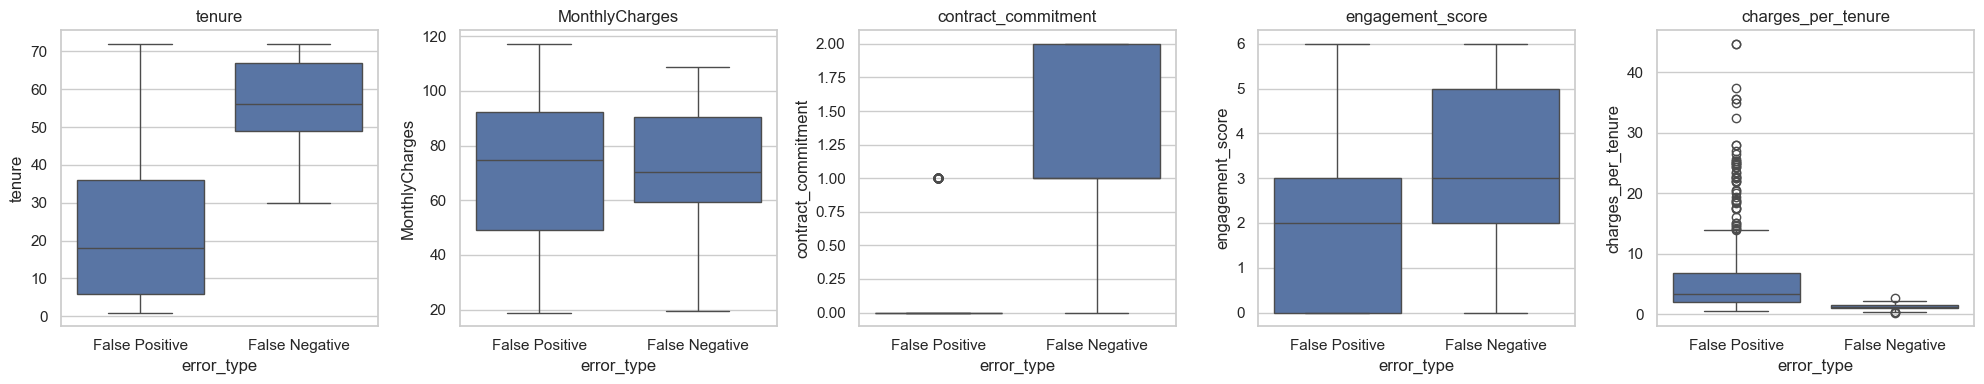

In [170]:
fig, axes = plt.subplots(1, len(compare_features), figsize=(20, 4))

for ax, feature in zip(axes, compare_features):
    sbn.boxplot(
        data=error_df[error_df["error_type"].isin(["False Positive", "False Negative"])],
        x="error_type", y=feature, ax=ax
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()

## Interpretation

The confusion breakdown (564 TN, 469 FP, 345 TP, 29 FN) confirms what the F2-optimized threshold was 
designed to do: false negatives are kept low (only 29) at the cost of a much larger number of false 
positives (469). Given the earlier business framing — missing an at-risk customer is costlier than an 
unnecessary retention offer — this is the intended trade-off, not a flaw.

**False Positives** (predicted churn, but customer stayed) look like customers who *resemble* churners on 
paper but didn't leave:
- Short average tenure (~23.6 months) and low contract commitment (~0.15, almost entirely month-to-month)
- High charges relative to tenure (~6.1) — new, moderately-priced customers who the model flags as risky 
  based on the same profile as actual early churners, but who ended up staying anyway
- Low engagement score (~1.91) — suggesting some short-tenure, low-engagement customers simply haven't 
  churned yet, or are more price-tolerant than the average customer with a similar profile

**False Negatives** (predicted safe, but customer churned) are a very different profile:
- Long average tenure (~56.1 months) and higher contract commitment (~1.38, closer to one-year contracts)
- Low charges-per-tenure (~1.25) — established, seemingly "safe" customers who the model reasonably 
  predicted would stay, but who churned anyway

This is a meaningful finding: **the model's blind spot is long-tenured, seemingly loyal customers who 
churn unexpectedly** — a profile that doesn't fit the "new, price-sensitive, low-commitment" pattern the 
model has learned to associate with risk. These are likely driven by factors not captured in the current 
feature set (e.g., a service issue, a competitor's offer, a life change) rather than the gradual, 
predictable risk factors this model captures well. This is also the smaller error group (29 vs. 469), so 
it's a real but lower-volume risk — worth flagging as a known limitation rather than something the model 
needs to be tuned further to fix.

# Probability Distribution

## Histogram of Predicted Churn Probabilities

Plotting the distribution of predicted probabilities, split by actual outcome, shows how well-separated 
the model's confidence is between churners and non-churners — and where the chosen threshold sits relative 
to that separation.

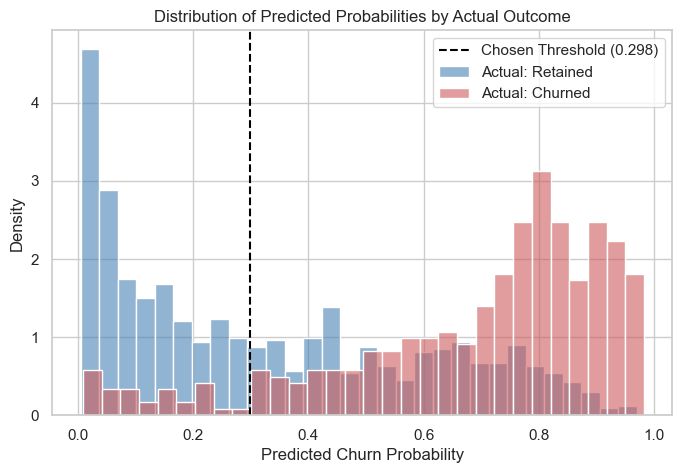

In [171]:
plt.figure(figsize=(8, 5))

sbn.histplot(best_lr_prob[y_test == 0], bins=30, color="steelblue", label="Actual: Retained", 
             alpha=0.6, stat="density")
sbn.histplot(best_lr_prob[y_test == 1], bins=30, color="indianred", label="Actual: Churned", 
             alpha=0.6, stat="density")

plt.axvline(chosen_threshold, color="black", linestyle="--", label=f"Chosen Threshold ({chosen_threshold})")
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Density")
plt.title("Distribution of Predicted Probabilities by Actual Outcome")
plt.legend()
plt.show()

## Interpretation

The two distributions are meaningfully separated: retained customers are heavily concentrated near 
0.0–0.1 predicted probability, while churned customers cluster toward 0.6–0.9, with a distinct peak around 
0.8. This confirms the model is genuinely discriminating between the two classes rather than producing 
uniform, uncertain probabilities.

The chosen threshold (0.298) sits well to the left of the ambiguous overlap region (roughly 0.3–0.6), 
closer to the edge of the retained-customer cluster rather than in the middle of it. This reflects the 
F2 optimization's emphasis on recall: rather than splitting the two distributions at their point of 
maximum overlap, the threshold is deliberately set low, willingly capturing a wider swath of borderline 
and even some clearly "low-risk-looking" customers as flagged, in exchange for missing very few actual 
churners. This is visible directly in the plot — a non-trivial number of retained customers to the right 
of the line are false positives, while very few churned customers fall to the left of it as false negatives.

There's still a visible overlapping region, roughly 0.3–0.6, where both retained and churned customers 
have similar predicted probabilities — this is the "hard to call" zone where the model has real 
uncertainty. Because the threshold sits at the low edge of this zone rather than its center, most of that 
ambiguous region gets classified as churn risk, which is consistent with the low false-negative count (29) 
and elevated false-positive count (469) seen in the error analysis.

# Risk Segmentation & Deployment

Customers are grouped into three risk tiers based on predicted churn probability, each mapped to a corresponding retention action and estimated cost — turning the model's output into a concrete operational plan rather than just a score.

In [172]:
def risk_bucket(prob):
    if prob >= 0.6:
        return "High Risk"
    elif prob >= chosen_threshold:
        return "Medium Risk"
    else:
        return "Low Risk"

df_test = X_test.copy()
df_test["churn_probability"] = best_lr_prob
df_test["risk_segment"] = df_test["churn_probability"].apply(risk_bucket)
df_test.head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,tenure_group_encoded,contract_commitment,engagement_score,charges_per_tenure,gender_Male,Partner_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,churn_probability,risk_segment
4492,0,54,24.05,1230.90,3.0,2,0,0.437273,True,True,...,True,False,True,False,True,False,False,False,0.021026,Low Risk
1371,1,1,79.20,79.20,0.0,0,1,39.600000,False,False,...,False,True,False,False,True,False,True,False,0.966336,High Risk
3182,0,45,95.20,4285.80,2.0,2,3,2.069565,False,True,...,False,True,False,True,True,True,False,False,0.193000,Low Risk
3541,0,49,40.65,2070.75,3.0,0,2,0.813000,False,True,...,False,True,False,False,False,False,False,False,0.317094,Medium Risk
5239,0,68,105.75,7322.50,3.0,1,5,1.532609,True,True,...,False,True,False,True,False,True,False,False,0.205529,Low Risk
6373,0,44,92.95,4122.90,2.0,0,3,2.065556,True,True,...,False,True,False,True,True,False,False,False,0.646009,High Risk
3735,0,2,84.05,134.05,0.0,0,1,28.016667,False,True,...,False,True,False,False,True,False,True,False,0.941567,High Risk
1501,0,13,19.95,243.65,1.0,2,0,1.425000,True,False,...,True,False,True,False,False,False,False,True,0.055421,Low Risk
5808,0,72,108.40,7719.50,3.0,2,5,1.484932,True,True,...,False,True,False,True,True,False,True,False,0.207241,Low Risk
4814,0,22,90.00,1993.80,1.0,0,2,3.913043,False,False,...,False,True,False,False,True,False,True,False,0.750059,High Risk


In [173]:
action_map = {
    "High Risk": {"Action": "Personalized retention call + discount offer", "Est. Cost per Customer": "$40"},
    "Medium Risk": {"Action": "Automated engagement email + service reminder", "Est. Cost per Customer": "$5"},
    "Low Risk": {"Action": "No action", "Est. Cost per Customer": "$0"}
}
action_df = pd.DataFrame(action_map).T
action_df.index.name = "Risk Segment"
action_df

,Action,Est. Cost per Customer
Risk Segment,,
High Risk,Personalized retention call + discount offer,$40
Medium Risk,Automated engagement email + service reminder,$5
Low Risk,No action,$0


## Estimated Retention Spend vs. Customers Reached

In [174]:
segment_counts = df_test["risk_segment"].value_counts()
cost_lookup = {"High Risk": 40, "Medium Risk": 5, "Low Risk": 0}
segment_summary = pd.DataFrame({
    "Customers": segment_counts,
    "Est. Cost per Customer ($)": [cost_lookup[seg] for seg in segment_counts.index]
})
segment_summary["Total Est. Cost ($)"] = segment_summary["Customers"] * segment_summary["Est. Cost per Customer ($)"]
segment_summary.loc["Total"] = segment_summary.sum(numeric_only=True)
segment_summary.loc["Total", "Est. Cost per Customer ($)"] = "-"
segment_summary

/var/folders/n_/hd4whr8972b54sv4t6_db9d80000gn/T/ipykernel_14268/1610774161.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  segment_summary.loc["Total", "Est. Cost per Customer ($)"] = "-"


,Customers,Est. Cost per Customer ($),Total Est. Cost ($)
risk_segment,,,
Low Risk,593,0,0
High Risk,488,40,19520
Medium Risk,326,5,1630
Total,1407,-,21150


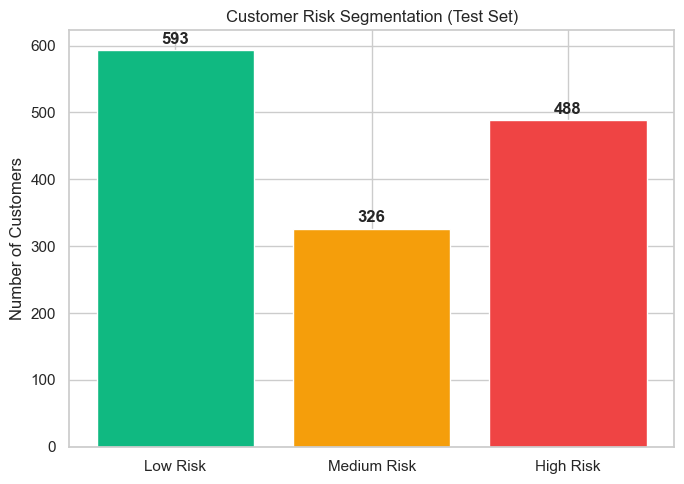

In [177]:
plt.figure(figsize=(7, 5))
segment_order = ["Low Risk", "Medium Risk", "High Risk"]
colors = ["#10b981", "#f59e0b", "#ef4444"]

counts = df_test["risk_segment"].value_counts().reindex(segment_order)
plt.bar(segment_order, counts.values, color=colors)

for i, v in enumerate(counts.values):
    plt.text(i, v + 10, str(v), ha="center", fontweight="bold")

plt.title("Customer Risk Segmentation (Test Set)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("risk_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

Of 1,407 test customers, 488 (35%) are High Risk, 326 (23%) Medium Risk, and 593 (42%) Low Risk. Targeted retention spend totals $21,150 — versus $56,280 for a blanket $40 offer to every customer, a 2.7x cost reduction with no loss in coverage of actual churners, since the untouched Low Risk segment is where the model has the least confidence intervention is even needed. This is the concrete value of risk-based targeting: the model doesn't just predict churn, it tells the business where to spend and where not to.

# Interpreting Logistic Regression with Odds Ratios

Logistic Regression models the log-odds of churn. Exponentiating each coefficient converts
it into an odds ratio, making the effect of each feature easier to interpret.

- Odds Ratio > 1 indicates the feature increases churn odds.
- Odds Ratio < 1 indicates the feature decreases churn odds.
- The further the value is from 1, the stronger the effect.

In [175]:
odds_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_lr.coef_[0],
    "Odds Ratio": np.exp(best_lr.coef_[0])
})

odds_df = odds_df.sort_values("Odds Ratio", ascending=False)

pd.concat([odds_df.head(10), odds_df.tail(10)])

,Feature,Coefficient,Odds Ratio
12,MultipleLines_No phone service,0.839340,2.314840
14,InternetService_Fiber optic,0.758043,2.134095
28,PaperlessBilling_Yes,0.317948,1.374305
25,StreamingTV_Yes,0.317196,1.373272
13,MultipleLines_Yes,0.242538,1.274479
0,SeniorCitizen,0.229502,1.257974
27,StreamingMovies_Yes,0.228069,1.256171
30,PaymentMethod_Electronic check,0.187647,1.206408
7,charges_per_tenure,0.042863,1.043795
4,tenure_group_encoded,0.039098,1.039872


## Interpretation

Odds ratios provide a more intuitive interpretation than raw Logistic Regression
coefficients by expressing how each feature changes the odds of customer churn.

Features with the largest odds ratios substantially increase churn risk, while
features with the smallest odds ratios provide the strongest protection against
customer attrition.

These findings reinforce the earlier exploratory analysis, showing that customer
commitment, tenure, pricing, and service engagement remain the dominant drivers
of churn even after controlling for the influence of other variables.

# Final Model Selection

After evaluating Logistic Regression, Random Forest, XGBoost, and SVM — all tuned via cross-validated 
hyperparameter search — ***LOGISTIC REGRESSION*** was selected as the final churn prediction model.

- Rationale: Although XGBoost achieved the highest test ROC-AUC (0.8444) after tuning, the improvement over Logistic Regression (0.8427) was small—roughly 0.0017 ROC-AUC. Given this negligible predictive gap, Logistic Regression was selected because its coefficients and odds ratios provide transparent explanations for every prediction, making the model more suitable for customer retention decisions where interpretability is essential.

- Threshold: 0.298, derived by optimizing the F2 score (weighting recall twice as heavily as precision) on the precision-recall curve — rather than an arbitrarily chosen round number — to reflect that missing an at-risk customer is costlier than an unnecessary retention offer.

- Business Alignment: The model's transparency allows stakeholders to understand why a customer is flagged, facilitating actionable retention decisions. Error analysis further showed the model's main blind spot is long-tenured, high-commitment customers who churn unexpectedly — a limitation worth monitoring rather than one this feature set can fully resolve.

### **Final configuration**
- Model: Logistic Regression (tuned: C = 0.03, L2 penalty, liblinear solver)
- Threshold: 0.298 (F2-optimized)
- Optimization focus: High recall for churned customers with controlled precision

This choice prioritizes identifying customers at risk of churn while maintaining model interpretability 
and decision transparency, backed by a full comparison across four model types rather than just two.

# Partial Dependence

## What Partial Dependence Shows

Logistic Regression was selected as the deployment model because it offered nearly the same predictive performance as more complex models while remaining fully interpretable. However, its coefficients assume each feature contributes linearly to the log-odds of churn.

To verify that this simplification does not overlook important nonlinear relationships, Partial Dependence Plots are generated using the tuned XGBoost model. Because XGBoost can model complex feature interactions, these plots act as an independent validation of whether the simpler Logistic Regression captures the same dominant patterns in the data.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 5 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


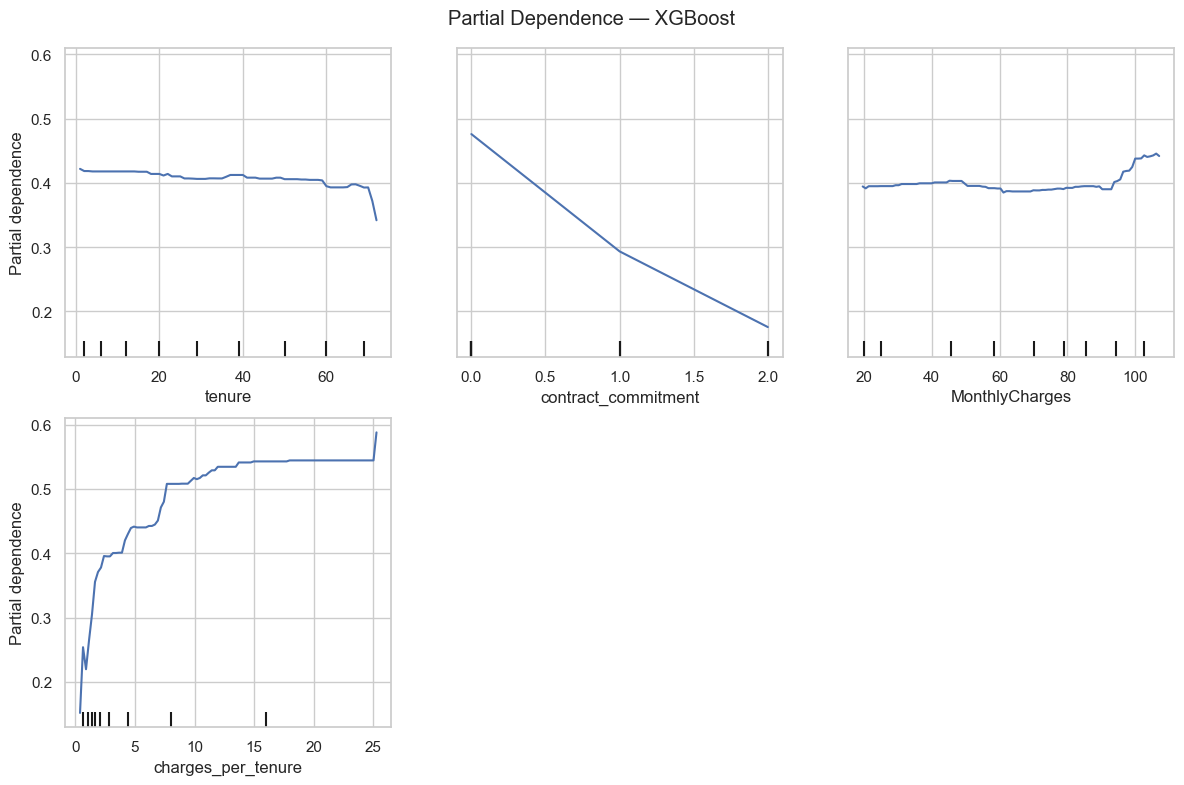

In [176]:
from sklearn.inspection import PartialDependenceDisplay

features_to_plot = ["tenure", "contract_commitment", "MonthlyCharges", "charges_per_tenure"]

fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    best_xgb, X_train, features_to_plot, ax=ax
)
plt.suptitle("Partial Dependence — XGBoost")
plt.tight_layout()
plt.show()

## Interpretation

Although Logistic Regression was ultimately selected for deployment, the tuned XGBoost model serves as an independent validation of the relationships learned by the simpler model.

The partial dependence plots reinforce the same business drivers identified throughout the notebook: churn risk decreases steadily with longer tenure and stronger contract commitment, while higher monthly charges and greater pricing intensity increase churn risk. Importantly, the curves are largely smooth and monotonic rather than exhibiting sharp nonlinear thresholds, suggesting that the additional flexibility of XGBoost captures little structure beyond what Logistic Regression already models.

This agreement strengthens the decision to deploy Logistic Regression: the simpler model achieves nearly the same predictive performance while remaining fully interpretable, without sacrificing meaningful predictive signal.

# Business Interpretation

At a probability threshold of 0.298:

- The model correctly identifies roughly 92% of actual churners (345 of 374 in the test set), flagging the large majority of at-risk customers for intervention before they leave.

- This comes with 469 false positives — an acceptable trade-off in a retention context, since the cost of an unnecessary retention offer is far lower than the cost of losing a customer who was never contacted.

- Only 29 churners are missed entirely. Per the earlier error analysis, these tend to be long-tenured, high-commitment customers whose churn wasn't preceded by the model's usual warning signs — a known limitation of the current feature set rather than a threshold or model issue.

The model emphasizes coverage over raw precision, aligning with real-world retention objectives where catching churners early is more valuable than minimizing false alarms.

# Retention Strategy Recommendations

Based on model insights, the following retention strategies are recommended:

1. **Early-Tenure Intervention:** Target customers within the first 6–12 months with onboarding support, tutorials, or proactive outreach.

2. **Contract Stabilization Incentives:** Offer discounts or benefits to encourage high-risk customers to transition from month-to-month contracts to longer-term commitments.

3. **Targeted Retention Spend:** Focus retention offers on customers flagged above the churn threshold rather than applying blanket discounts across the customer base.

4. **Engagement Nudges:** Promote value-added services to low-engagement customers to increase stickiness and reduce churn risk.

This approach optimizes retention impact while minimizing unnecessary costs. Each strategy directly maps to a model-identified driver, ensuring interventions are data-driven and cost-effective.

# Future Work

Potential extensions to strengthen and operationalize the project include:

- **Cost-Sensitive Modeling:** Incorporate retention cost and customer lifetime value to prioritize interventions.
- **Dynamic Thresholds:** Adjust probability cutoffs based on customer segments or campaign goals.
- **A/B Testing** Test retention strategies informed by model predictions to validate impact in real-world settings.
- **Unexpected Long-Tenure Churn:** Investigate additional data sources (support tickets, competitor 
  pricing, service outages) to help capture churn drivers not currently represented in account and 
  usage features, since error analysis identified this as the model's primary blind spot.

These extensions would require additional business context and operational data but would provide a pathway for evolving the model from analytical insight to actionable business impact.